<h1 style="text-align: center;"> Customer Churn Prediction and Retention Strategy Analysis with Business Impact Simulation </h1>

### Executive Summary & Strategic Objectives

**Business Problem**  
The purpose of this project is to identify customers at risk of churn using machine learning and estimate the potential financial impact of targeted retention interventions.

**Objectives**🔍  
1. What is the descriptive relationship of tenure, monthly charges, and total charges with customer churn status?
2. Can customer churn be predicted using tenure, monthly charges, and total charges?
3. Which classification method, Logistic Regression or k-Nearest Neighbors, provides better predictive performance for customer churn?
4. How can predicted churn probabilities be used to identify high-risk customers for targeted retention efforts?
5. What is the estimated financial impact of targeting high-risk customers with a retention intervention?

In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import seaborn as sns
%matplotlib inline


<h2 style="text-align: center;"> Data Engineering & Validation </h2>

In [2]:
# Read the Telco datafile
df = pd.read_csv('Telco-Customer-Churn.csv') # Data source: https://github.com/IBM/telco-customer-churn-on-icp4d

# Take a quick look at the dataframe
print(df['Churn'].value_counts())
df.head()


Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

### Diagnostics

In [5]:
def var_diagnostic(df, var): 
    """Diagnostic information about an individual variable"""
    print(f"--------------- Diagnostic Info: {var} ---------------" )
    print("Descriptive info: \n", df[var].describe())
    print("Unique Values: \n", df[var].unique()[: 10])
    print("Variable Type: \n", df[var].dtypes)
    print("Missing values: \n", df[var].isna().sum())
    print("------------------------- End -------------------------" )

In [6]:
var_diagnostic(df, 'TotalCharges')
var_diagnostic(df, 'MonthlyCharges')
var_diagnostic(df, 'tenure')
var_diagnostic(df, 'Churn')

--------------- Diagnostic Info: TotalCharges ---------------
Descriptive info: 
 count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object
Unique Values: 
 ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']
Variable Type: 
 object
Missing values: 
 0
------------------------- End -------------------------
--------------- Diagnostic Info: MonthlyCharges ---------------
Descriptive info: 
 count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Unique Values: 
 [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
Variable Type: 
 float64
Missing values: 
 0
------------------------- End -------------------------
--------------- Diagnostic Info: tenure ---------------
Descriptive info: 
 count    7043.000000
mean       32.371149
std        24.559

In [7]:
# For potential/hidden empty spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

In [8]:
# Convert Churn into categorical and Total Charges (int) into float
df['Churn'] = df['Churn'].astype('category')
df['Churn'] = df['Churn'].map({'Yes':1, 'No': 0})
df['TotalCharges'] = df['TotalCharges'].astype('float')

### Variables

#### Features:
- **Total Charges:** The cumulative total amount of money the customer has paid the company over their entire lifespan up to the current quarter
- **Monthly Charges:** The exact dollar amount billed to the customer each month for all their combined services (e.g., internet, phone lines, device protection)
- **Tenure:** The total number of months the customer has stayed with the telecom company

#### Response Variable:
**Churn:** 
- Yes: The customer terminated their contract and left the company during the designated quarter.
- No: The customer remained active and stayed with the telecom company

In [9]:
var_diagnostic(df, 'TotalCharges')
var_diagnostic(df, 'MonthlyCharges')
var_diagnostic(df, 'tenure')
var_diagnostic(df, 'Churn')

--------------- Diagnostic Info: TotalCharges ---------------
Descriptive info: 
 count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64
Unique Values: 
 [  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95]
Variable Type: 
 float64
Missing values: 
 11
------------------------- End -------------------------
--------------- Diagnostic Info: MonthlyCharges ---------------
Descriptive info: 
 count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Unique Values: 
 [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
Variable Type: 
 float64
Missing values: 
 0
------------------------- End -------------------------
--------------- Diagnostic Info: t

In [10]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[features].shape

(7043, 3)

### Handling Missing Data

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # (11 missing values in Total Charges) Fills new customers with 0
df['TotalCharges'].isna().sum()

np.int64(0)

### Diagnostics for Outliers

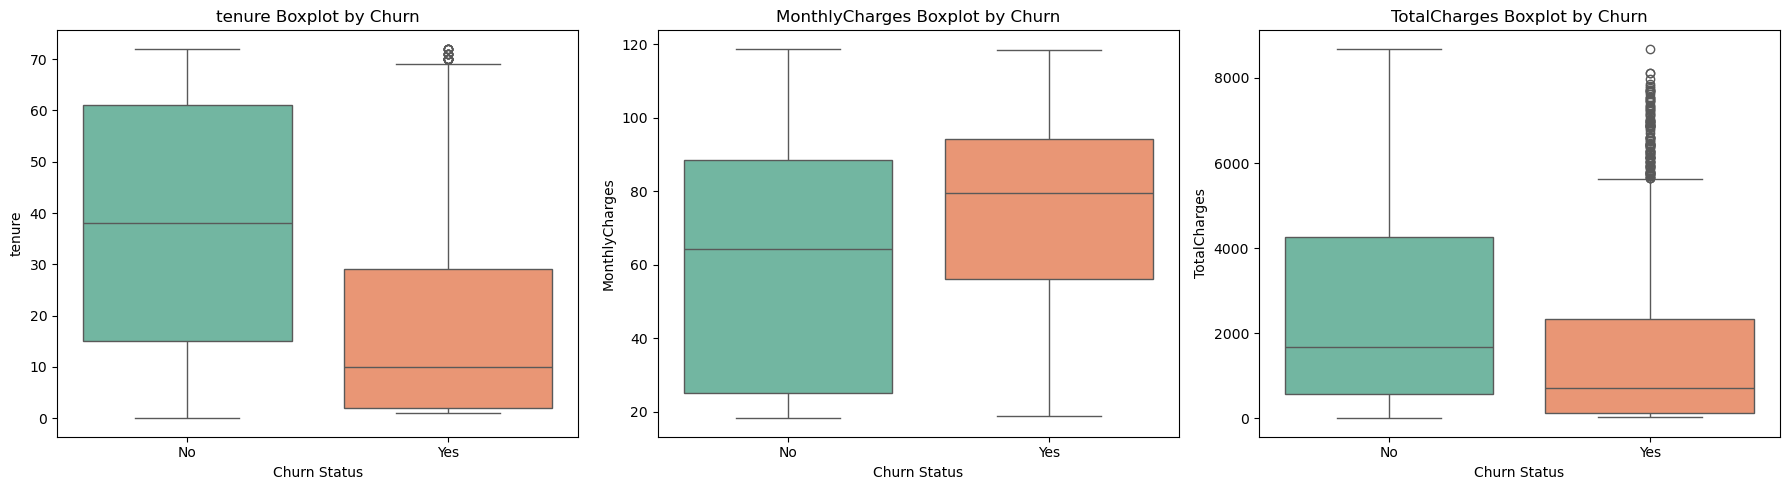

In [12]:

# Create a figure with 1 row and 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create a temporary copy to keep labels as "No" and "Yes"
df_plot = df.copy()
df_plot['Churn'] = df_plot['Churn'].map({0: 'No', 1: 'Yes'})

for i, var in enumerate(features):
    # x is the grouping variable, y is the continuous feature
    # legend=False turns off individual legend boxes since the x-axis is already clear
    sns.boxplot(data=df_plot, x='Churn', y=var, hue='Churn', 
                palette='Set2', ax=axes[i], legend=False)
    
    axes[i].set_title(f'{var} Boxplot by Churn')
    axes[i].set_xlabel('Churn Status')
    axes[i].set_ylabel(var)

plt.tight_layout() # Prevents labels from overlapping between plots
plt.savefig('features_boxplots.png', dpi=300, bbox_inches='tight')

plt.show()


In [13]:
# Isolate the churned customers 
churned = df[df['Churn'].isin([1])].copy()
def outliers_detection(var, features): 
    """Calculating and reporting outliers"""
    # Calculate Interquartile range (IQR) components for TotalCharges
    q1 = churned[var].quantile(0.25)
    q3 = churned[var].quantile(0.75)
    iqr = q3-q1
    
    # Define the upper outlier fence 
    upper_fence = q3 + (1.5*iqr)
    print(f"\nStatistically, any churned customer with {var} value over ${upper_fence:.2f} is an outlier.\n")
    
    # Filter using the exact statistical boundary
    var_outlier = churned[churned[var] > upper_fence]
    
    print(f"Found {len(var_outlier)} statistical outliers for {var}:")
    print(var_outlier[features].head())
    print("-------------------------------------")
    
outliers_detection('TotalCharges', features)
outliers_detection('MonthlyCharges', features)
outliers_detection('tenure', features)


Statistically, any churned customer with TotalCharges value over $5626.50 is an outlier.

Found 109 statistical outliers for TotalCharges:
     tenure  MonthlyCharges  TotalCharges
104      68          110.00       7611.85
339      63          103.40       6603.00
402      69           99.45       7007.60
445      60          105.90       6396.45
609      65          105.25       6786.40
-------------------------------------

Statistically, any churned customer with MonthlyCharges value over $151.28 is an outlier.

Found 0 statistical outliers for MonthlyCharges:
Empty DataFrame
Columns: [tenure, MonthlyCharges, TotalCharges]
Index: []
-------------------------------------

Statistically, any churned customer with tenure value over $69.50 is an outlier.

Found 23 statistical outliers for tenure:
      tenure  MonthlyCharges  TotalCharges
811       70          104.00       7250.15
975       71          108.05       7532.15
1306      70          115.55       8127.60
2879      70        

**Checking the Validity of Outliers:**

In [14]:
# Isolate churned customers 
churned = df[df['Churn'].isin([1])].copy()

# Find the statistical outlier threshold
q1 = churned['TotalCharges'].quantile(0.25)
q3 = churned['TotalCharges'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + (1.5 * iqr)

# Filter for just the outliers
outliers = churned[churned['TotalCharges'] > upper_fence].copy()

print(f"Analyzing {len(outliers)} total outliers...")

# LOGIC TEST: Calculate expected charges
# We use .get_width or direct math: tenure * MonthlyCharges
outliers['Expected_Total'] = outliers['tenure'] * outliers['MonthlyCharges']

# Calculate the percentage difference between reality and theory
outliers['Percent_Difference'] = (
    (outliers['TotalCharges'] - outliers['Expected_Total']).abs() / outliers['Expected_Total']) * 100

# Flag rows where the mismatch is greater than 15% (System Errors)
# If tenure is 0, Expected_Total is 0, which can cause a divide-by-zero 
system_errors = outliers[outliers['Percent_Difference'] > 15]
valid_outliers = outliers[outliers['Percent_Difference'] <= 15]

print(f"✅ Valid Outliers found: {len(valid_outliers)} (Real high-value customers to KEEP)")
print(f"❌ System Errors found: {len(system_errors)} (Data glitches to REMOVE or FIX)")

if len(system_errors) > 0:
    print("\nReviewing the data glitches:")
    print(system_errors[['tenure', 'MonthlyCharges', 'TotalCharges', 'Expected_Total', 'Percent_Difference']])


Analyzing 109 total outliers...
✅ Valid Outliers found: 109 (Real high-value customers to KEEP)
❌ System Errors found: 0 (Data glitches to REMOVE or FIX)


> **Summary for Outliers Check:**  
- No outliers was found that could be due to system errors.
- While the average total charge for churned customers is relatively low, the box plot reveals a segment of high-value outliers who churned despite contributing significant lifetime revenue.
- Because these are highly loyal, long-term customers who used the products of the company for many years and spent significantly more money, but eventually cancelled their service during the last quarter, these data points are considered valid data points.

### Data Quality Assurance & Logic Assertion Checks

In [15]:
# Negative Balance Check
assert df[(df['MonthlyCharges'] <0) | (df['TotalCharges'] < 0)].shape[0] == 0, \
    "Data Error: Negative charges exist in the dataset!"
assert df[df['tenure'] < 0].shape[0] == 0, \
    "Data Error: Negative tenure values!"

In [16]:
# New Customer Balance Check
assert df[(df['tenure'] ==0) & (df['TotalCharges'] > 0)].shape[0] ==0, \
    "Logic Error: Customers with 0 tenure has Total Charges > $0"

In [17]:
# Total Charges Check related to being equivalent to (Tenure * Monthly Charges)
# A previous check showed that two cases revealed Logic Error, which might be due 
# to starting with a more expensive product and then switching it. 
# We should filter for tenure > 5
assert len(df[(df['tenure'] > 5) & (df['TotalCharges'] > (df['tenure'] * df['MonthlyCharges'] * 1.5))]) == 0, \
    "Logic Error: TotalCharges is physically impossible relative to tenure and monthly rates!"

In [18]:
# Create a temporary column to calculate the threshold
expected_limit = df['tenure'] * df['MonthlyCharges'] * 1.5
problem_rows = df[(df['tenure'] > 5) & (df['TotalCharges'] > expected_limit)]

print(f"Found {len(problem_rows)} problematic rows:")
print(problem_rows[['tenure', 'MonthlyCharges', 'TotalCharges']])

Found 0 problematic rows:
Empty DataFrame
Columns: [tenure, MonthlyCharges, TotalCharges]
Index: []


<h2 style="text-align: center;"> Exploratory Data Analysis 📊 </h2>

#### Overview of Features

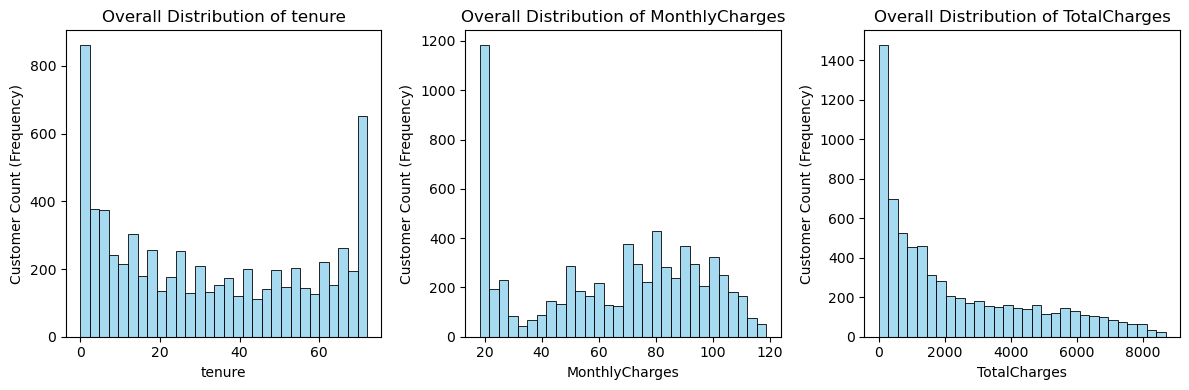

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, var in enumerate(features):
    # Plain histogram without the 'hue' parameter
    sns.histplot(data=df, x=var, bins=30, color='skyblue', edgecolor='black', ax=axes[i])
    
    axes[i].set_title(f'Overall Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Customer Count (Frequency)')

plt.tight_layout()

**Key Findings**  
The continuous predictors (tenure, MonthlyCharges, and TotalCharges) are highly non-normal, exhibiting severe right-skewness and bimodal structures. Because continuous inputs exhibit severe right-skewness and bimodal distribution profiles, forcing a linear model architecture induces heteroscedasticity, rendering standard errors and significance parameters invalid. Consequently, Logistic Regression and K-Nearest Neighbors (KNN) Classification are utilized as robust alternatives.

> **Caveat 1:** Highly skewed columns like TotalCharges can act like outliers and warp the decision boundary line, leading to poorer predictions. Log transformation is necessary.  
> **Caveat 2:** KNN is incredibly sensitive to the scale of the data. Because TotalCharges runs into thousands of dollars while tenure only goes up to 72 months, KNN will completely underestimate tenure. The features must be scaled.

### Objective 1: What is the descriptive relationship of tenure, monthly charges, and total charges with customer churn status?

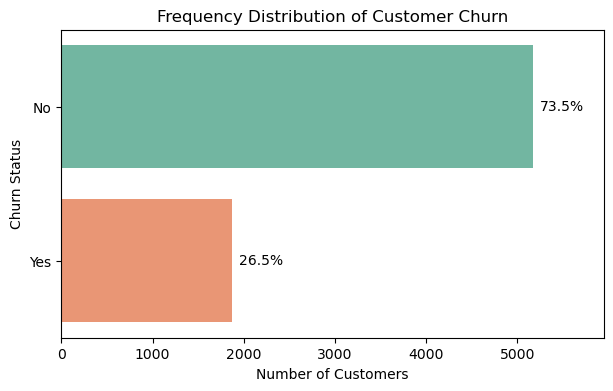

In [20]:
plt.figure(figsize=(7, 4))

# Create a temporary copy
df_plot = df.copy()
df_plot['Churn'] = df_plot['Churn'].map({0: 'No', 1: 'Yes'})

# Store the plot in 'ax'
ax = sns.countplot(data=df_plot, y='Churn', hue='Churn', palette='Set2', legend=False)

# Calculate the total number of rows
total_customers = len(df_plot)

# Loop through the horizontal bars and label them with percentages
for container in ax.containers:
    # Calculate percentages on the fly using a lambda function
    labels = [f'{(bar.get_width() / total_customers * 100):.1f}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=5)

plt.title('Frequency Distribution of Customer Churn')
plt.xlabel('Number of Customers') 
plt.ylabel('Churn Status')
plt.xlim(0, df_plot['Churn'].value_counts().max() * 1.15) # Adds breathing room for labels
plt.savefig('churn_frequency.png', dpi=300, bbox_inches='tight')

plt.show()


> **Key Findings**📊   
> The dataset indicates a distinct class imbalance, where 73.5% of the customer base stayed (No) and 26.5% churned (Yes) during the last quarter. While this roughly 3-to-1 ratio accurately reflects real-world telecom attrition rates, it represents a significant revenue leak.

#### Quick Overview of Feature Means

In [21]:
group_means = df.groupby('Churn', observed=False)[features].mean().T
group_means.columns = ['Stayed (No)', 'Churned (Yes)']
print(group_means)

                Stayed (No)  Churned (Yes)
tenure            37.569965      17.979133
MonthlyCharges    61.265124      74.441332
TotalCharges    2549.911442    1531.796094


> **Key Findings** 📊  
> People who are less tenure, charged more per month, and with lower cumulative total amount of money paid to the company have a positive relation with churning. 

**Correlation Between Feature Variables**

In [22]:
df[features].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


> **Key Findings** 📊  
> - All three features are positively correlated
> - Naturally, the total number of months the customer has stayed with the telecom company is highly correlated with the cumulative total amount of money paid to the company over their entire lifespan
> - The lowest correlation is between monthly charges and the total number of months the customer has stayed with the telecom company

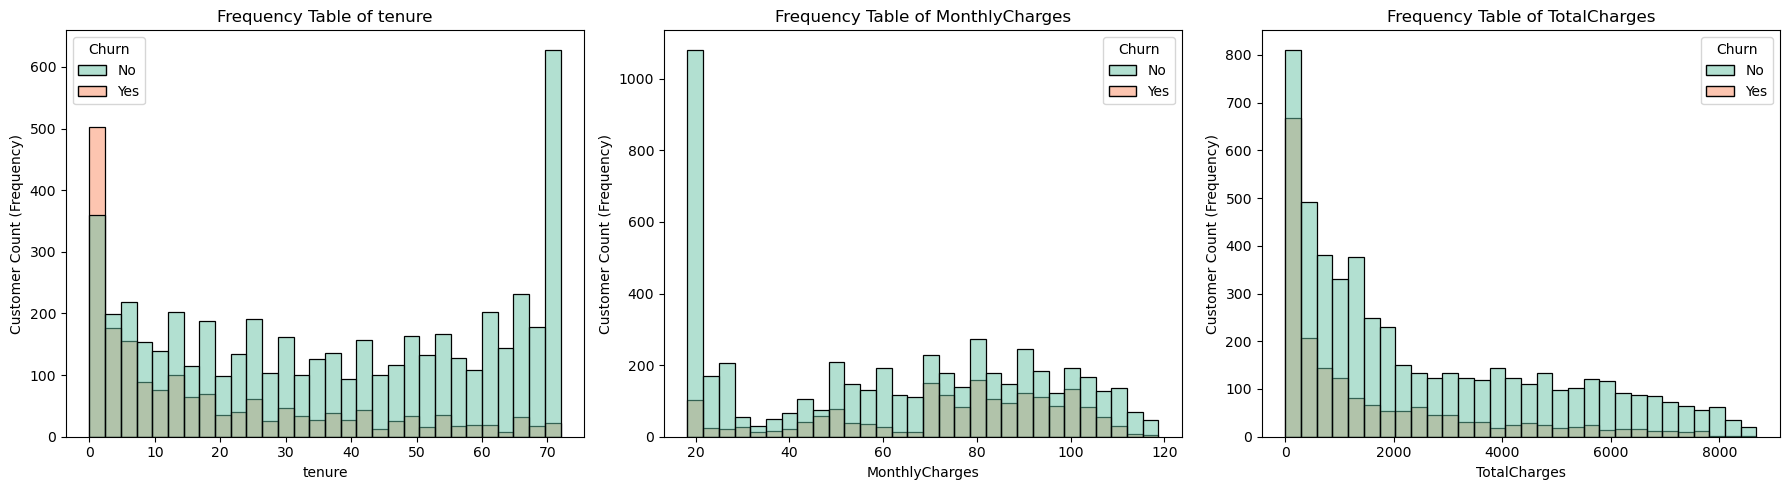

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(features):
    # Changed to histplot for actual frequencies
    # element="step" or multiple="layer" keeps the overlapping clean
    sns.histplot(data=df_plot, x=var, hue='Churn', palette='Set2', 
                 multiple='layer', alpha=0.5, bins=30, ax=axes[i])
    
    axes[i].set_title(f'Frequency Table of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Customer Count (Frequency)') # y-axis is now a true count

plt.tight_layout()
plt.savefig('features_frequency.png', dpi=300, bbox_inches='tight')


> **Key Findings** 📊  
> - New customer are more likely churn in comparison with old customers. They are the least satisfied group.
> - Increase in monthly charges is associated with higher rate of people who churn 
> - Customers who has higher cumulative total amount of money paid to the company over their entire lifespan have lower rate of churning.

<h2 style="text-align: center;"> Predictive Modeling 📊 </h2>

### Objective 2: Can customer churn be predicted using tenure, monthly charges, and total charges?

### Train-Test Split

In [24]:
# Split the data into train and test sets with 70% for training data
# To prevent data leakage, separate CSVs are created.
df_train, df_test = train_test_split(df, train_size=0.7, random_state=60)

In [25]:
df_train.sample(5)

,tenure,MonthlyCharges,TotalCharges,Churn
6770,4,78.90,299.75,0
4457,22,75.00,1573.95,0
522,55,85.50,4713.40,0
4973,13,93.80,1261.00,0
6974,51,98.85,4947.55,0


In [26]:
# Save the train data
# To prevent from creating duplicate index columns, exclude the default indices
df_train.to_csv("df_train.csv", index=False)

# Save the test data
df_test.to_csv("df_test.csv", index=False)


In [27]:
# Read the datafile "df_train.csv"
df_train = pd.read_csv('df_train.csv') 

# Take a quick look at the dataframe
df_train.head()

,tenure,MonthlyCharges,TotalCharges,Churn
0,69,74.1,5031.00,0
1,35,81.6,2815.25,0
2,19,69.6,1394.55,0
3,5,24.3,100.20,0
4,66,99.5,6710.50,1


In [28]:
# Read the datafile "fd_test.csv"
df_test = pd.read_csv('df_test.csv')
# Take a quick look at the dataframe
df_test.head()

,tenure,MonthlyCharges,TotalCharges,Churn
0,61,96.50,5673.70,0
1,37,96.10,3646.80,0
2,56,85.60,4902.80,0
3,1,49.55,49.55,1
4,1,80.15,80.15,1


In [29]:
df_train.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [30]:
# Get the train predictors
X_train = df_train[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Get the train response variable
y_train = df_train['Churn']


In [31]:
# Get the test predictors
X_test = df_test[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Get the test response variable
y_test = df_test['Churn']


### k-Nearest Neighbors Model

**Hyperparameter Tuning: Finding the best k**

In [32]:
# Choosing k range from 1 to 70
k_value_min = 1
k_value_max = 70

# Create a list of evenly integer k values to test as hyperparameters
k_list = np.linspace(k_value_min, k_value_max, num=70, dtype=int)


In [33]:
# Scaling the features

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# Create a dictionary to store the k value for model accuracy
knn_dict = {}

# Loop over all k values
for k_value in k_list:
    k_num = int(k_value)
    if k_num > X_train_scaled.shape[0]:
        break
    # Create a KNN Classificaiton model for the current k
    model = KNeighborsClassifier(n_neighbors=k_num)
    
    # Fit the model on the train data
    model.fit(X_train_scaled,y_train)
    
    # Use the trained model to predict on the test data
    y_pred = model.predict(X_test_scaled)
    
    model_accuracy = accuracy_score(y_test, y_pred)
    #print(f"For k={k_value}, Model Accuracy is {model_accuracy}")

    # Store the model accuracy of each k value in the dictionary
    knn_dict[k_num] = model_accuracy

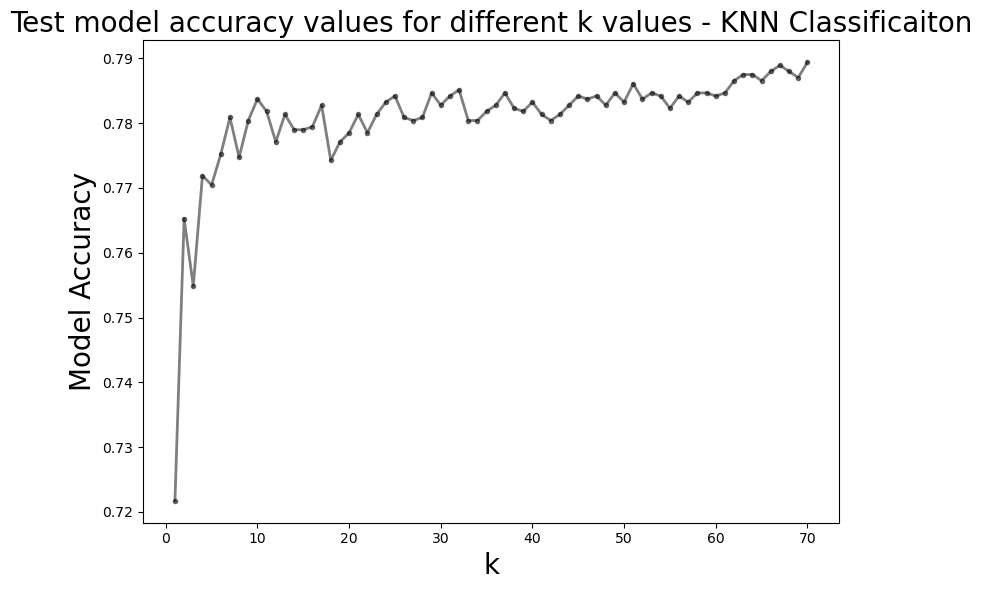

In [35]:
# Plot a graph which depicts the relation between the k values and model accuracy
plt.figure(figsize=(8,6))
plt.plot(list(knn_dict.keys()), list(knn_dict.values()),'k.-',alpha=0.5,linewidth=2)

# Set the title and axis labels
plt.xlabel('k',fontsize=20)
plt.ylabel('Model Accuracy',fontsize = 20)
plt.title('Test model accuracy values for different k values - KNN Classificaiton',fontsize=20)
plt.tight_layout()
plt.savefig('model_accuracy_k_values.png', dpi=300, bbox_inches='tight')

In [36]:
max_model_accuracy = max(knn_dict.values())
tolerance = 0.005  # Adjust as needed for bias-variance tradeoff, 0.002

# Find smallest k whose accuracy is within the tolerance of the maximum accuracy
best_k_robust = min([k for k, model_accuracy in knn_dict.items() if abs(model_accuracy - max_model_accuracy) <= tolerance])

print(f"Highest Model Accuracy: {max_model_accuracy:.3f}")
print(f"Optimal smallest k achieving higher accuracy with tolerance range of 0.005: {best_k_robust}")

Highest Model Accuracy: 0.789
Optimal smallest k achieving higher accuracy with tolerance range of 0.005: 29


#### KNN Model

In [37]:
# Define the classification model
knn_model = KNeighborsClassifier(n_neighbors=best_k_robust, weights='distance')
# Note: closer neighbors get a much stronger vote than further neighbors, protecting (imbalanced) 
# minority clusters from being overwhelmed

# Fit the model on the train data
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,29
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
# Predict and compute the accuracy on the test data
y_pred = knn_model.predict(X_test_scaled)

model_accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy is {model_accuracy}")

Model Accuracy is 0.7785139611926172


### Logistic Regresssion Model

In [39]:
# Define a Logistic Regression model with max_iter as 10000 and C as 0.1 (leave all other parameters at default values)
log_model = LogisticRegression(max_iter = 10000, C = 0.1, class_weight='balanced') # To balance the classes we use class_weight
# C is the regularization strength; 0.01 is very high. default is 1, 10 to 100 is low regularization

# Fit the Logistic Regression model on the train data
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


## Model Evaluation

### Objective 3: Which classification method, Logistic Regression or k-Nearest Neighbors, provides better predictive performance for customer churn?

To compare models, the metrics below are utilized:  

<table style="width:100%; border: 1px solid black; border-collapse: collapse;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 10px; border: 1px solid black; text-align: left;">Metric Name</th>
    <th style="padding: 10px; border: 1px solid black; text-align: center;">Mathematical Formula</th>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid black;"><b>Accuracy</b></td>
    <td style="padding: 10px; border: 1px solid black; text-align: center;">$\frac{TP + TN}{TP + TN + FP + FN}$</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid black;"><b>Recall</b> (Sensitivity)</td>
    <td style="padding: 10px; border: 1px solid black; text-align: center;">$\frac{TP}{TP + FN}$</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid black;"><b>Specificity</b></td>
    <td style="padding: 10px; border: 1px solid black; text-align: center;">$\frac{TN}{TN + FP}$</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid black;"><b>Precision</b></td>
    <td style="padding: 10px; border: 1px solid black; text-align: center;">$\frac{TP}{TP + FP}$</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid black;"><b>F1-Score</b></td>
    <td style="padding: 10px; border: 1px solid black; text-align: center;">$2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$</td>
  </tr>
</table>


To use these metrics, create a dictionary called metric_scores which has keys 'Accuracy', 'Recall', 'Specificity', 'Precision', and 'F1-score'; the first element being KNN Classification Model corresponding metric score and the second element being Logistic Regression Model corresponding metric score. 

In [40]:
metric_scores = {}

#Generate predictions on the scaled test features
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_log = log_model.predict(X_test_scaled)

# Extract confusion_matrix for kNN
tn_k, fp_k, fn_k, tp_k = confusion_matrix(y_test, y_pred_knn).ravel()

# Extract confusion_matrix for logistic regression
tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_log).ravel()

metric_scores['Accuracy'] = [
    (tp_k + tn_k) / (tp_k + tn_k + fp_k + fn_k),
    (tp_l + tn_l) / (tp_l + tn_l + fp_l + fn_l)
]

metric_scores['Recall'] = [
    tp_k / (tp_k + fn_k),
    tp_l / (tp_l + fn_l)
]

metric_scores['Specificity'] = [
    tn_k / (tn_k + fp_k),
    tn_l / (tn_l + fp_l)
]

metric_scores['Precision'] = [
    tp_k / (tp_k + fp_k),
    tp_l / (tp_l + fp_l)
]

metric_scores['F1-score'] = [
    (2 * tp_k) / (2 * tp_k + fp_k + fn_k),
    (2 * tp_l) / (2 * tp_l + fp_l + fn_l)
]

# Print to verify the exact structural lengths and keys
print(metric_scores)



{'Accuracy': [np.float64(0.7785139611926172), np.float64(0.7340274491244676)], 'Recall': [np.float64(0.44869565217391305), np.float64(0.7513043478260869)], 'Specificity': [np.float64(0.9018205461638491), np.float64(0.7275682704811444)], 'Precision': [np.float64(0.6308068459657702), np.float64(0.5076380728554641)], 'F1-score': [np.float64(0.524390243902439), np.float64(0.605890603085554)]}


In [41]:
# Display your results
df_model_results = pd.DataFrame(metric_scores, index=['kNN Model', 'Logistic Regression Model'])
df_formatted = (df_model_results.T*100).map(lambda x: f"{x:.1f}%")
display(df_formatted)

,kNN Model,Logistic Regression Model
Accuracy,77.9%,73.4%
Recall,44.9%,75.1%
Specificity,90.2%,72.8%
Precision,63.1%,50.8%
F1-score,52.4%,60.6%


> **Key Insights:**  
> - Accuracy: kNN scores higher overall only because it leans heavily on the easier-to-predict majority class (customers who stay).  
> - Balanced Logistic Regression successfully identifies 75.1% of true churners. kNN misses a massive 55.1% of them.
> - kNN raises fewer false alarms, but it achieves this by being overly conservative and passive.
> - The significantly higher F1-score mathematically proves that Logistic Regression handles the dataset's class imbalance far more effectively.

### Model Diagnostics: ROC Curve & AUC Performance Analysis

In [42]:
# Define a kNN classification model with best k
knn = KNeighborsClassifier(n_neighbors=best_k_robust, weights='distance')

# Fit the above model on the train data
knn.fit(X_train_scaled, y_train)

# Predict probabilities for the positive class on the test data using the kNN model
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [43]:
# Define a Logistic Regression model with max_iter as 10000, C as 0.1, and a random_state of 42
logreg = LogisticRegression(max_iter=10000, C=0.1, random_state=42, class_weight='balanced') 


# Fit the Logistic Regression model on the train data
logreg.fit(X_train_scaled, y_train)

# Predict probabilities for the positive class on the test data using the logistic regression model
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

#### ROC (Receiver Operating Characteristic) Curve

The Bayes threshold of a binary classifier is the value at which all predicted probabilities are labelled as the positive class. The ROC curve shows a model's false positive and true positive rates at different Bayes threshold settings. 
$$\text{False Positive Rate} = \frac{FP}{TN + FP}$$
$$\text{True Positive Rate} = \frac{TP}{TP + FN}$$

Compute the false positve rate (FPR) and true positive rate (TPR) for a range of thresholds and use these values to plot ROC curves for both the kNN and the logistic regression models.

#### Thresholds

Thresholds define the decision boundary for converting probability predictions into binary class labels, with adjustments balancing model recall against precision. In this context, a threshold is a cut-off point for at-risk customers who might leave.
To avoid redundant computations and ensure precision in classification, optimal thresholds are derived from the unique, sorted probability scores rather than a static, predefined grid. Implement this dynamic approach by extracting unique probabilities to define critical shifts in model classification.

In [44]:
def get_thresholds(y_pred_proba):
    # Only consider unique predicted probabilities
    unique_probas = np.unique(y_pred_proba)
    # Sort unique probabilities in descending order
    unique_probas_sorted = unique_probas[::-1]

    # To ensure ROC curves reach the corners of the plot, (0,0) and (1,1) add some additional thresholds to the set
    # Insert 1.1 at the beginning of the threshold array: a value greater than 1
    # is required for the ROC curve to reach the lower left corner
    # (0 fpr, 0 tpr) considering one of our models produces probability predictions of 1
    thresholds = np.insert(unique_probas_sorted, 0, 1.1)
    # Append 0 to the end of the thresholds
    thresholds = np.append(thresholds, 0)
    return thresholds

# Note: This can also be done via sklearn.metrics.roc_curve

In [45]:
knn_thresholds = get_thresholds(y_prob_knn)

logreg_thresholds = get_thresholds(y_prob_logreg)

#### FPR & TPR

Now we can use the true $y$ class label and the predicted probabilities to determine the false postitive rate and true positive rate on the test data for a specific threshold. Complete the `get_fpr` and `get_tpr` functions below.

In [46]:
def get_fpr(y_true, y_pred_proba, threshold):
    # Ensure threshold behaves as a list or array
    if isinstance(threshold, (int, float, np.number)):
        threshold = [threshold]

    # Pre-calculate the total number of actual negatives (denominator) once
    # This completely eliminates the need to run confusion_matrix() over and over
    total_negatives = (y_true == 0).sum()
    
    fpr_list = []
    for t in threshold: 
        # NumPy vectorized step: count where model predicts 1 but actual is 0
        fp = ((y_pred_proba >= t) & (y_true == 0)).sum()
        fpr_list.append(fp / total_negatives)
        
    return fpr_list[0] if len(fpr_list) == 1 else np.array(fpr_list)

In [47]:
def get_tpr(y_true, y_pred_proba, threshold):
    if isinstance(threshold, (int, float, np.number)):
        threshold = [threshold]

    total_positives = (y_true == 1).sum()
    
    tpr_list = []
    for t in threshold: 
        tp = ((y_pred_proba >= t) & (y_true == 1)).sum()
        tpr_list.append(tp / total_positives)
        
    return tpr_list[0] if len(tpr_list) == 1 else np.array(tpr_list)

In [48]:
# FPR for the kNN at each of its thresholds
knn_fpr = get_fpr(y_test, y_prob_knn, knn_thresholds)
# TPR for the kNN at each of its thresholds
knn_tpr = get_tpr(y_test, y_prob_knn, knn_thresholds)

# TPR for the logistic model at each of its thresholds
logreg_tpr = get_tpr(y_test, y_prob_logreg, logreg_thresholds)
# FPR for the logistic model at each of its thresholds
logreg_fpr = get_fpr(y_test, y_prob_logreg, logreg_thresholds)

#### Area Under the Curve (AUC)

- The AUC gives us an idea as to how well the model does across thresholds.
- For our final calculations, use each model's predicted probabilities to compute its test AUC with the help of SKLearn's `roc_auc_score` function.

In [49]:
# Compute the ROC AUC score of the kNN model
knn_auc = roc_auc_score(y_test, y_prob_knn)

# Compute the ROC AUC score of the Logistic model 
logreg_auc = roc_auc_score(y_test, y_prob_logreg)

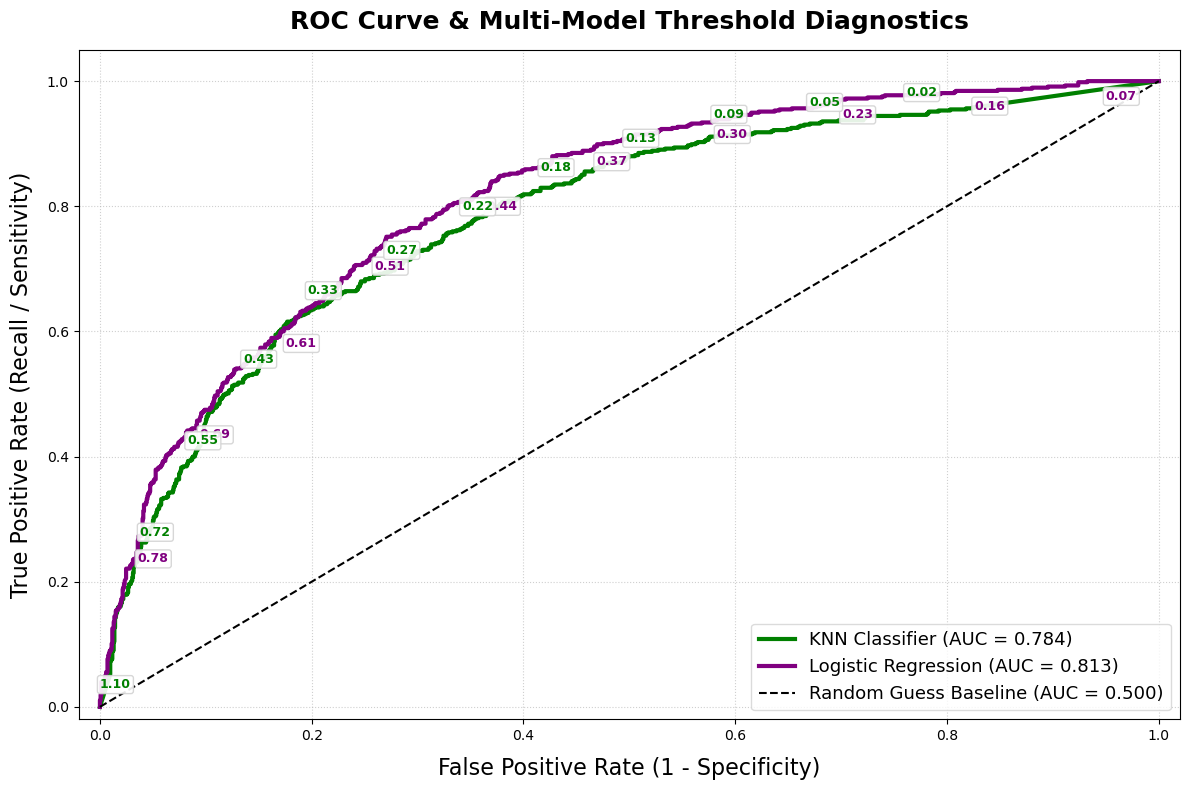

In [50]:
# Initialize the plot canvas size
fig, ax = plt.subplots(figsize=(12, 8))

# Plot KNN Classifier ROC Curve
ax.plot(knn_fpr,
        knn_tpr,
        label=f'KNN Classifier (AUC = {knn_auc:.3f})',
        color='g',
        lw=3)

# Plot Balanced Logistic Regression ROC Curve
ax.plot(logreg_fpr,
        logreg_tpr,
        label=f'Logistic Regression (AUC = {logreg_auc:.3f})',
        color='purple',
        lw=3)

# Threshold annotations configuration
label_kwargs = {}
label_kwargs['bbox'] = dict(
    boxstyle='round, pad=0.3', facecolor='white', edgecolor='lightgray', alpha=0.8
)
eps = 0.025 # Visual spacing offset so text labels don't clip the curve line

# Annotate Logistic Regression thresholds
label_kwargs = {}
label_kwargs['bbox'] = dict(
    boxstyle='round, pad=0.2', facecolor='white', edgecolor='lightgray', alpha=0.9
)
eps = 0.03 # Spacing offset

# Set steps to 200 to spread out the purple labels
for i in range(0, len(logreg_fpr), 200):
    if i < len(logreg_thresholds):
        threshold = f"{logreg_thresholds[i]:.2f}"
        ax.annotate(threshold, (logreg_fpr[i], logreg_tpr[i] - eps), 
                    fontsize=9, color='purple', weight='bold', **label_kwargs)

# Set steps to 150 to spread out the green labels
for i in range(0, len(knn_fpr), 150):
    if i < len(knn_thresholds):
        threshold = f"{knn_thresholds[i]:.2f}"
        ax.annotate(threshold, (knn_fpr[i], knn_tpr[i] + eps), 
                    fontsize=9, color='green', weight='bold', **label_kwargs)


# Plot diagonal line representing a random classifier
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess Baseline (AUC = 0.500)')

# Graph boundaries, styling, and labels configuration
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=16, labelpad=10)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=16, labelpad=10)

# Align with centered Jupyter Notebook rules
ax.set_title('ROC Curve & Multi-Model Threshold Diagnostics', fontsize=18, fontweight='bold', pad=15)
ax.legend(loc="lower right", fontsize=13, frameon=True, facecolor='white', edgecolor='lightgray')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')


> **Key Insights**  
> - This graph proves that continuous accounting metrics (tenure, MonthlyCharges, TotalCharges) contain strong, highly exploitable predictive signals regarding customer churn.  
> - This graph justifies that Logistic Regression beats KNN Classification as the core model for the customer retention pipeline.
> - Logistic Regression catches more true churners for the exact same amount of false alarms across nearly all thresholds

<h2 style="text-align: center;"> Data-Driven Strategic Recommendations 📊 </h2> 

## Objective 4: How can predicted churn probabilities be used to identify high-risk customers for targeted retention efforts?

### Simulate the Risk Tranches

In [51]:
# Create an intervention simulation DataFrame
sim_df = pd.DataFrame({
    'tenure': X_test['tenure'],
    'MonthlyCharges': X_test['MonthlyCharges'],
    'TotalCharges': X_test['TotalCharges'],
    'Churn_Probability': y_prob_logreg,
    'Actual_Churn': y_test
})

# Define business risk tranches based on probability thresholds from the ROC curve
conditions = [
    (sim_df['Churn_Probability'] >= 0.75),
    (sim_df['Churn_Probability'] >= 0.50) & (sim_df['Churn_Probability'] < 0.75),
    (sim_df['Churn_Probability'] >= 0.25) & (sim_df['Churn_Probability'] < 0.50),
    (sim_df['Churn_Probability'] < 0.25)
]
choices = ['1. Critical Risk', '2. High Risk', '3. Medium Risk', '4. Low Risk']
sim_df['Risk_Segment'] = np.select(conditions, choices, default='4. Low Risk')

# Display the volume and financial exposure of each segment
summary = sim_df.groupby('Risk_Segment').agg(
    Customer_Count=('Churn_Probability', 'count'),
    Avg_Monthly_Bill=('MonthlyCharges', 'mean'),
    Total_Monthly_Revenue_At_Risk=('MonthlyCharges', 'sum')
).round(2)

display(summary)


,Customer_Count,Avg_Monthly_Bill,Total_Monthly_Revenue_At_Risk
Risk_Segment,,,
1. Critical Risk,279,85.87,23957.45
2. High Risk,572,71.68,41003.35
3. Medium Risk,744,63.47,47224.35
4. Low Risk,518,49.34,25556.05


> **Key Insights**  
> - The Critical Risk segment has the highest average monthly bill of USD 85.87, while the Low Risk segment has the lowest of USD 49.34. Price sensitivity is the primary engine of customer defection. Retention efforts must prioritize accounts exceeding a \$80/month billing threshold, as they are the most volatile.
> - The top two high-risk segments (Critical and High Risk) contain 851 customers who represent a combined monthly revenue exposure of \$64,960.80 (\$23,957.45 + \$41,003.35). By focusing marketing interventions exclusively on these top two tiers (representing roughly 40% of the tested customer base), management can proactively safeguard over 60% of the total revenue currently flagged at risk across the company.
> - The Critical Risk tier holds 279 customers who have a high probability (≥ 0.75) of imminent defection. The High Risk tier holds 572 customers who are highly unstable but still winnable. For Critical Risk: Offer direct, high-value financial relief (e.g., a permanent contract downgrade or a \$15 monthly credit) tied to a mandatory 12-month contract renewal. For High Risk: Use non-revenue-diluting incentives (e.g., free premium streaming data, complimentary device protection, or router upgrades) to repair the relationship without permanently reducing contract yields.
> - The Medium Risk tier represents the single largest pool of endangered money in the dataset, totaling \$47,224.35 across 744 accounts.While these customers do not require immediate emergency discounts, they are slowly showing behaviors that lead to churn. Marketing teams should target this reservoir with proactive customer satisfaction surveys and usage optimizations to prevent them from sliding up into the Critical Risk tier over the next quarter.

## Objective 5: What is the estimated financial impact of targeting high-risk customers with a retention intervention?

#### Simulation: Estimating Financial Impact 

In [52]:
# Baseline parameters from  specific test outcomes
total_targeted_customers = 279 + 572  # Critical Risk + High Risk count = 851
total_monthly_revenue_at_risk = 23957.45 + 41003.35  # $64,960.80

# From the results matrix: Precision is 50.76%
# This means out of 851 targeted, 50.76% are actual churners, 49.24% are false alarms
precision_rate = 0.5076  
actual_churners_targeted = int(total_targeted_customers * precision_rate)  # 431 customers
false_alarms_targeted = total_targeted_customers - actual_churners_targeted  # 420 customers

# Strategic Intervention Assumptions (Adjust these variables as needed)
intervention_success_rate = 0.40  # Assume the company successfully saves 40% of the real churners they target
monthly_retention_offer_cost = 7.00  # The company offers a $15/month price drop/incentive to all 851 targeted accounts
customer_lifespan_months = 12  # Measure the financial impact over a 1-year contract extension

# Financial Calculations
customers_saved = int(actual_churners_targeted * intervention_success_rate)  # ~172 customers saved

# Revenue Saved: Saved customers * their average bill ($76.33 weighted avg) * 12 months
avg_bill_targeted = total_monthly_revenue_at_risk / total_targeted_customers
gross_revenue_saved = customers_saved * avg_bill_targeted * customer_lifespan_months

# Campaign Cost: Offering the discount to ALL 851 targeted customers for 12 months
total_campaign_cost = total_targeted_customers * monthly_retention_offer_cost * customer_lifespan_months

# Net Financial Impact
net_revenue_saved = gross_revenue_saved - total_campaign_cost
roi_percentage = (net_revenue_saved / total_campaign_cost) * 100

# --- DISPLAY THE RESULTS ---
print(f"============================================================")
print(f"      FINANCIAL ROI SIMULATION: RETENTION INTERVENTION      ")
print(f"============================================================")
print(f"Total High-Risk Customers Targeted : {total_targeted_customers} accounts")
print(f"True Churners Correctly Flagged    : {actual_churners_targeted} accounts")
print(f"Insurance Operating Cost (Safe Customers)      : {false_alarms_targeted} accounts")
print(f"------------------------------------------------------------")
print(f"Estimated Customers Saved (40% SR) : {customers_saved} accounts")
print(f"Gross Lifetime Revenue Protected   : USD {gross_revenue_saved:,.2f}")
print(f"Total 12-Month Campaign Cost       : USD {total_campaign_cost:,.2f}")
print(f"============================================================")
print(f"NET FINANCIAL BENEFIT (PROFIT)     : USD {net_revenue_saved:,.2f}")
print(f"RETURN ON INVESTMENT (ROI)         : {roi_percentage:.1f}%")
print(f"============================================================")


      FINANCIAL ROI SIMULATION: RETENTION INTERVENTION      
Total High-Risk Customers Targeted : 851 accounts
True Churners Correctly Flagged    : 431 accounts
Insurance Operating Cost (Safe Customers)      : 420 accounts
------------------------------------------------------------
Estimated Customers Saved (40% SR) : 172 accounts
Gross Lifetime Revenue Protected   : USD 157,554.75
Total 12-Month Campaign Cost       : USD 71,484.00
NET FINANCIAL BENEFIT (PROFIT)     : USD 86,070.75
RETURN ON INVESTMENT (ROI)         : 120.4%


**Key Findings:**  
> - For a high cost \$15 discount on monthly bill, Net Financial Benefit is **USD 4,374.75** with a **2.9%** Return on Investment
> - For a low cost \$2 discount on monthly bill (or other incentives), Net Financial Benefit is **USD 137,130.75** with a massive **671.4%** Return on Investment
> - For medium cost \$7 discount on monthly bill, Net Financial Benefit is **USD 86,070.75** with a still large **120.4%** Return on Investment